In [1]:
# Install specific libraries
!pip install transformers
!pip install wordcloud
!pip install --upgrade scikit-learn
!pip install optuna
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 84.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 0.22.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.10.0, but you have google-cloud-bigquery 2.34.4 which is incompatible.
bigframes 0.22.0 requires google-cloud-storage>=2.0.0, but you have google-cloud-storage 1.44.0 which is incompatible.
bigframes 0.22.0 requires pandas<2.1.4,>=1.5.0, but you have pandas 2.2.2 which is incompatible.
cesium 0.12.3 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
dataproc-jupyter-plugin 0.1.79 requires pydantic~=1.10.0, but you have pydantic 2.9.2 which is incompatible.


In [2]:
# Import libraries
import numpy as np
import pandas as pd
from wordcloud import WordCloud
from pylab import rcParams
import transformers
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, BertTokenizerFast, BertForSequenceClassification
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import optuna
from tqdm import tqdm 
from torch.utils.data import TensorDataset, DataLoader, RandomSampler
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format='retina'
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 12, 8

In [3]:
# Specify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Set seeds for reproducibility
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
torch.manual_seed(SEED_VALUE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_VALUE)

In [5]:
# Load Dataset
true_data = pd.read_csv('/kaggle/input/fakenewsdatasets/FakeNewsDataset/True.csv')
fake_data = pd.read_csv('/kaggle/input/fakenewsdatasets/FakeNewsDataset/Fake.csv')

# Combine datasets and add a label column
true_data['label'] = 0
fake_data['label'] = 1
data = pd.concat([fake_data, true_data], ignore_index=True)

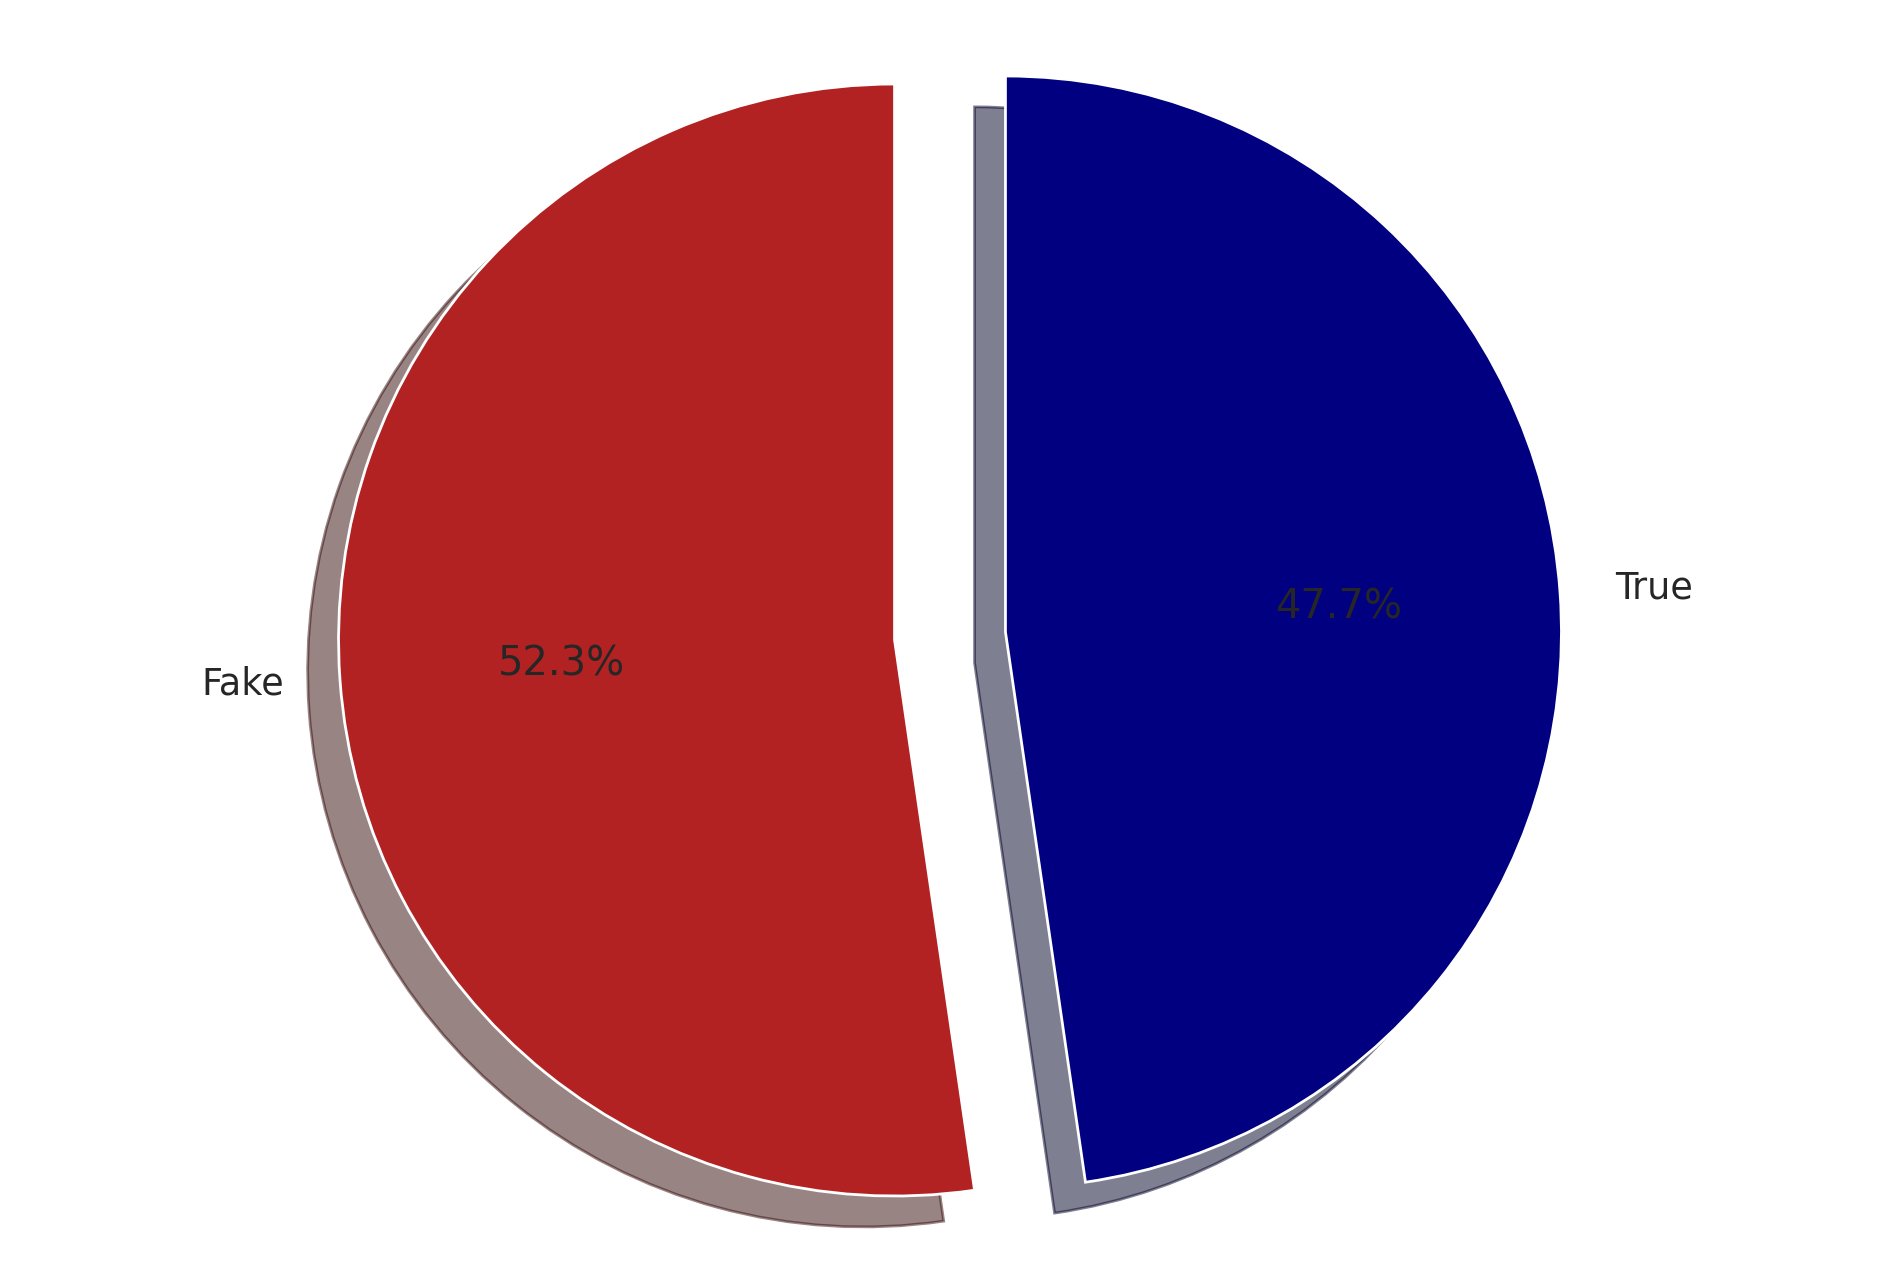

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      1  
1  December 31, 2017      1  
2  December 30, 2017      1  
3  December 29, 2017      1  
4  December 25, 2017      1  
label
1    23481
0    21417
Name: count, dtype: int64


In [6]:
# Checking if our data is well balanced
label_size = [data['label'].sum(), len(data['label']) - data['label'].sum()]
plt.pie(label_size, 
         explode=[0.1, 0.1], 
         colors=['firebrick', 'navy'], 
         startangle=90, 
         shadow=True, 
         labels=['Fake', 'True'],
         autopct='%1.1f%%')

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')  
plt.show()

# Data Exploration
print(data.head())
print(data['label'].value_counts())

In [7]:
# Train-Validation-Test set split into 70:15:15 ratio
train_text, temp_text, train_labels, temp_labels = train_test_split(data['title'], data['label'], random_state=SEED_VALUE, test_size=0.3)
val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels, random_state=SEED_VALUE, test_size=0.5)

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      1  
1  December 31, 2017      1  
2  December 30, 2017      1  
3  December 29, 2017      1  
4  December 25, 2017      1  
label
1    23481
0    21417
Name: count, dtype: int64


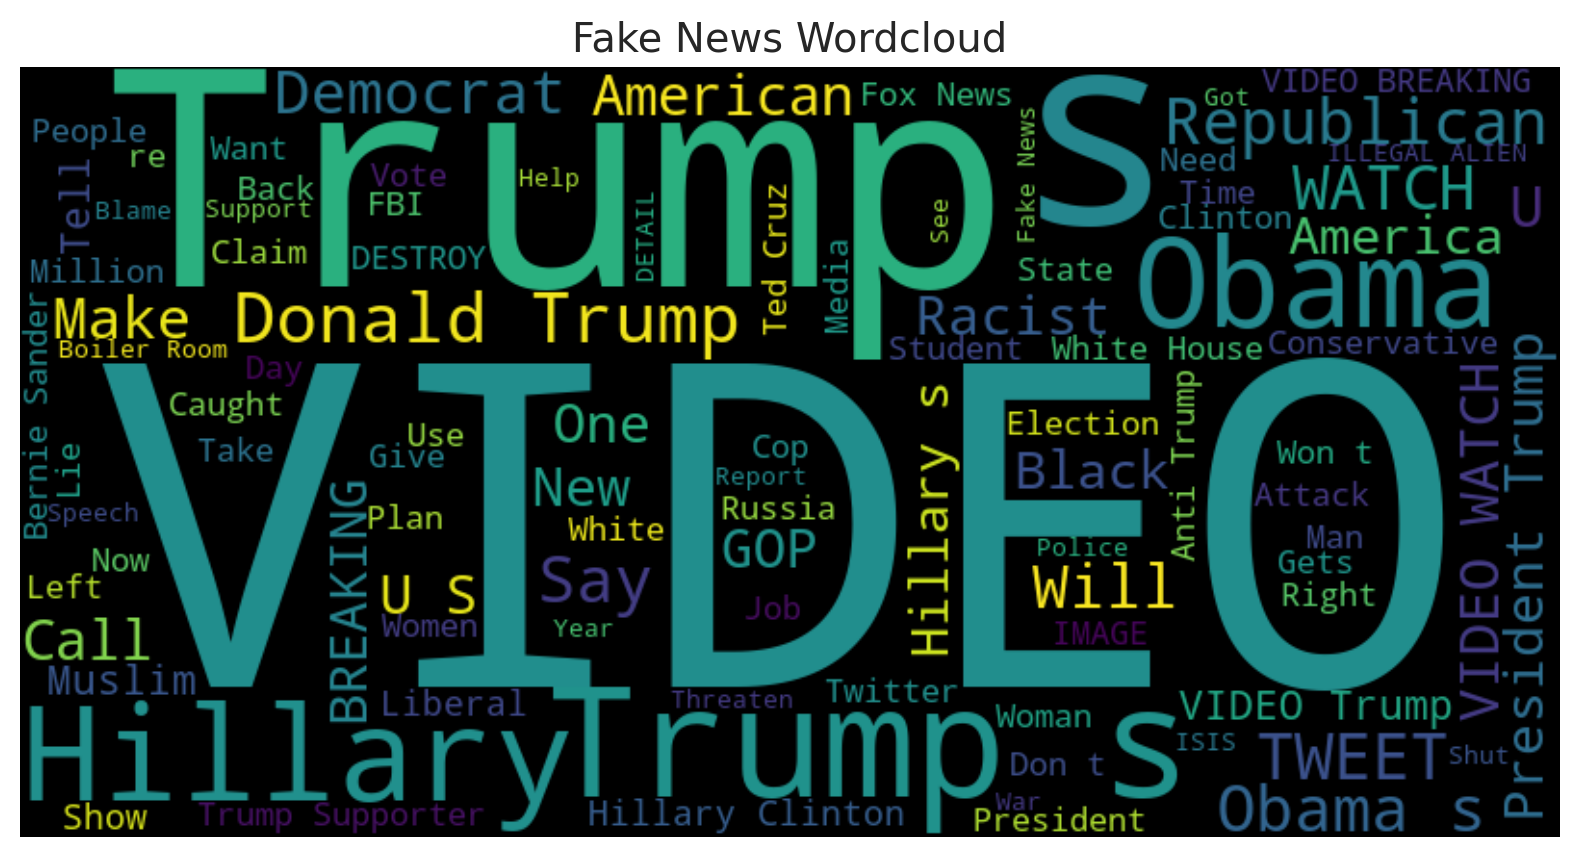

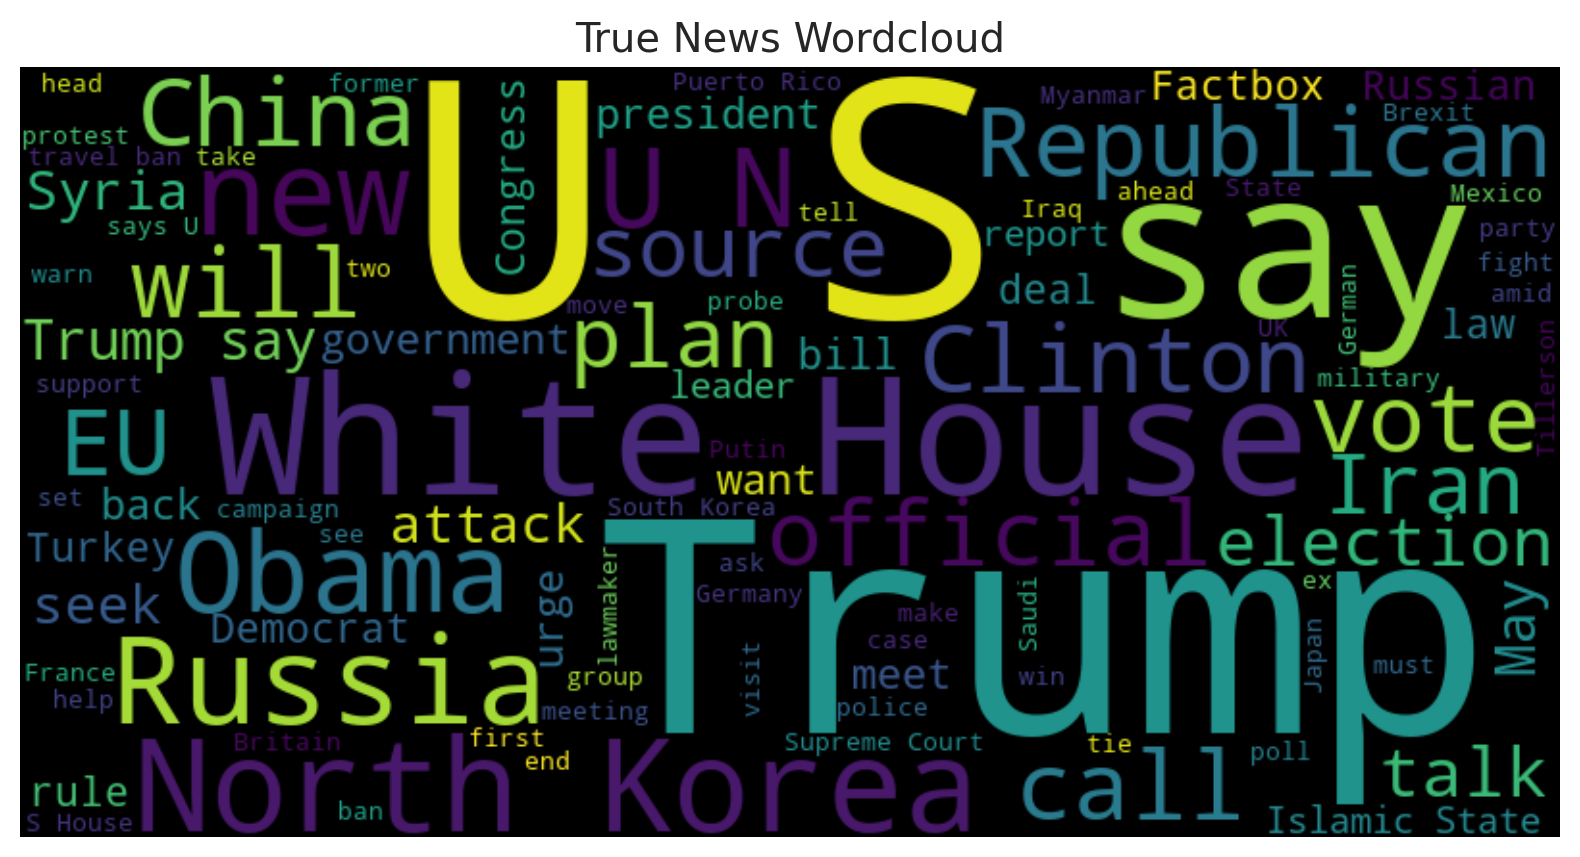

In [8]:
# Data Exploration
print(data.head())
print(data['label'].value_counts())

# Wordcloud for Fake and True News
fake_text = ' '.join(fake_data['title'])
true_text = ' '.join(true_data['title'])

fake_wordcloud = WordCloud(width=800, height=400, max_words=100).generate(fake_text)
true_wordcloud = WordCloud(width=800, height=400, max_words=100).generate(true_text)

plt.figure(figsize=(10, 5))
plt.imshow(fake_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Fake News Wordcloud')
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(true_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('True News Wordcloud')
plt.show()

Text(0, 0.5, 'Number of texts')

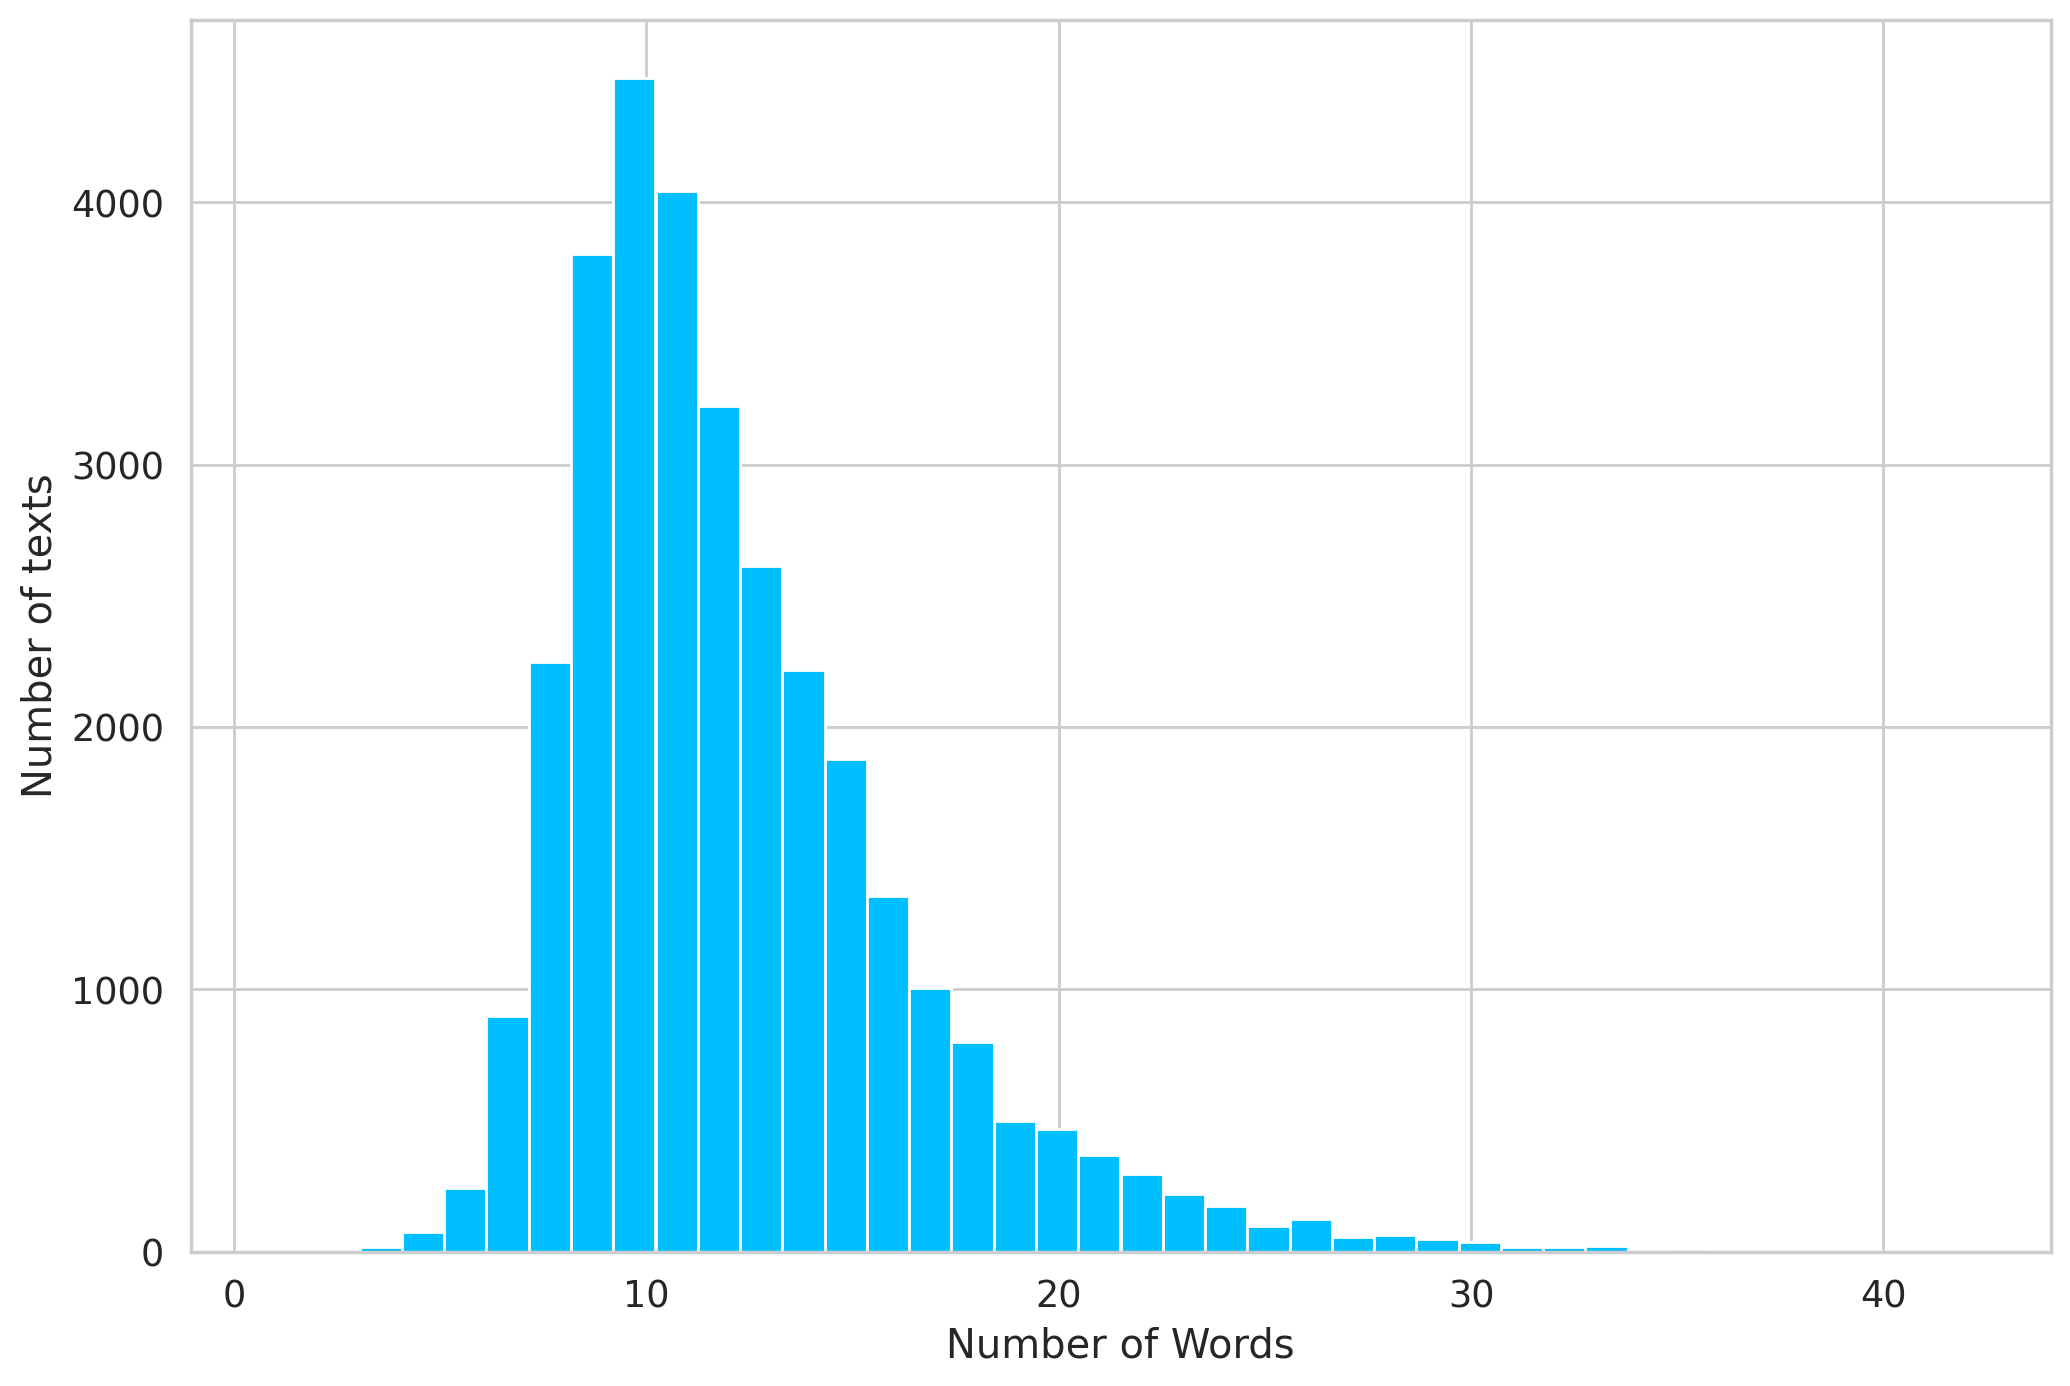

In [9]:
# Plot histogram of the number of words in train data 'text'
seq_len = [len(title.split()) for title in train_text]
pd.Series(seq_len).hist(bins = 40)
plt.xlabel('Number of Words')
plt.ylabel('Number of texts')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Maximum token length: 63


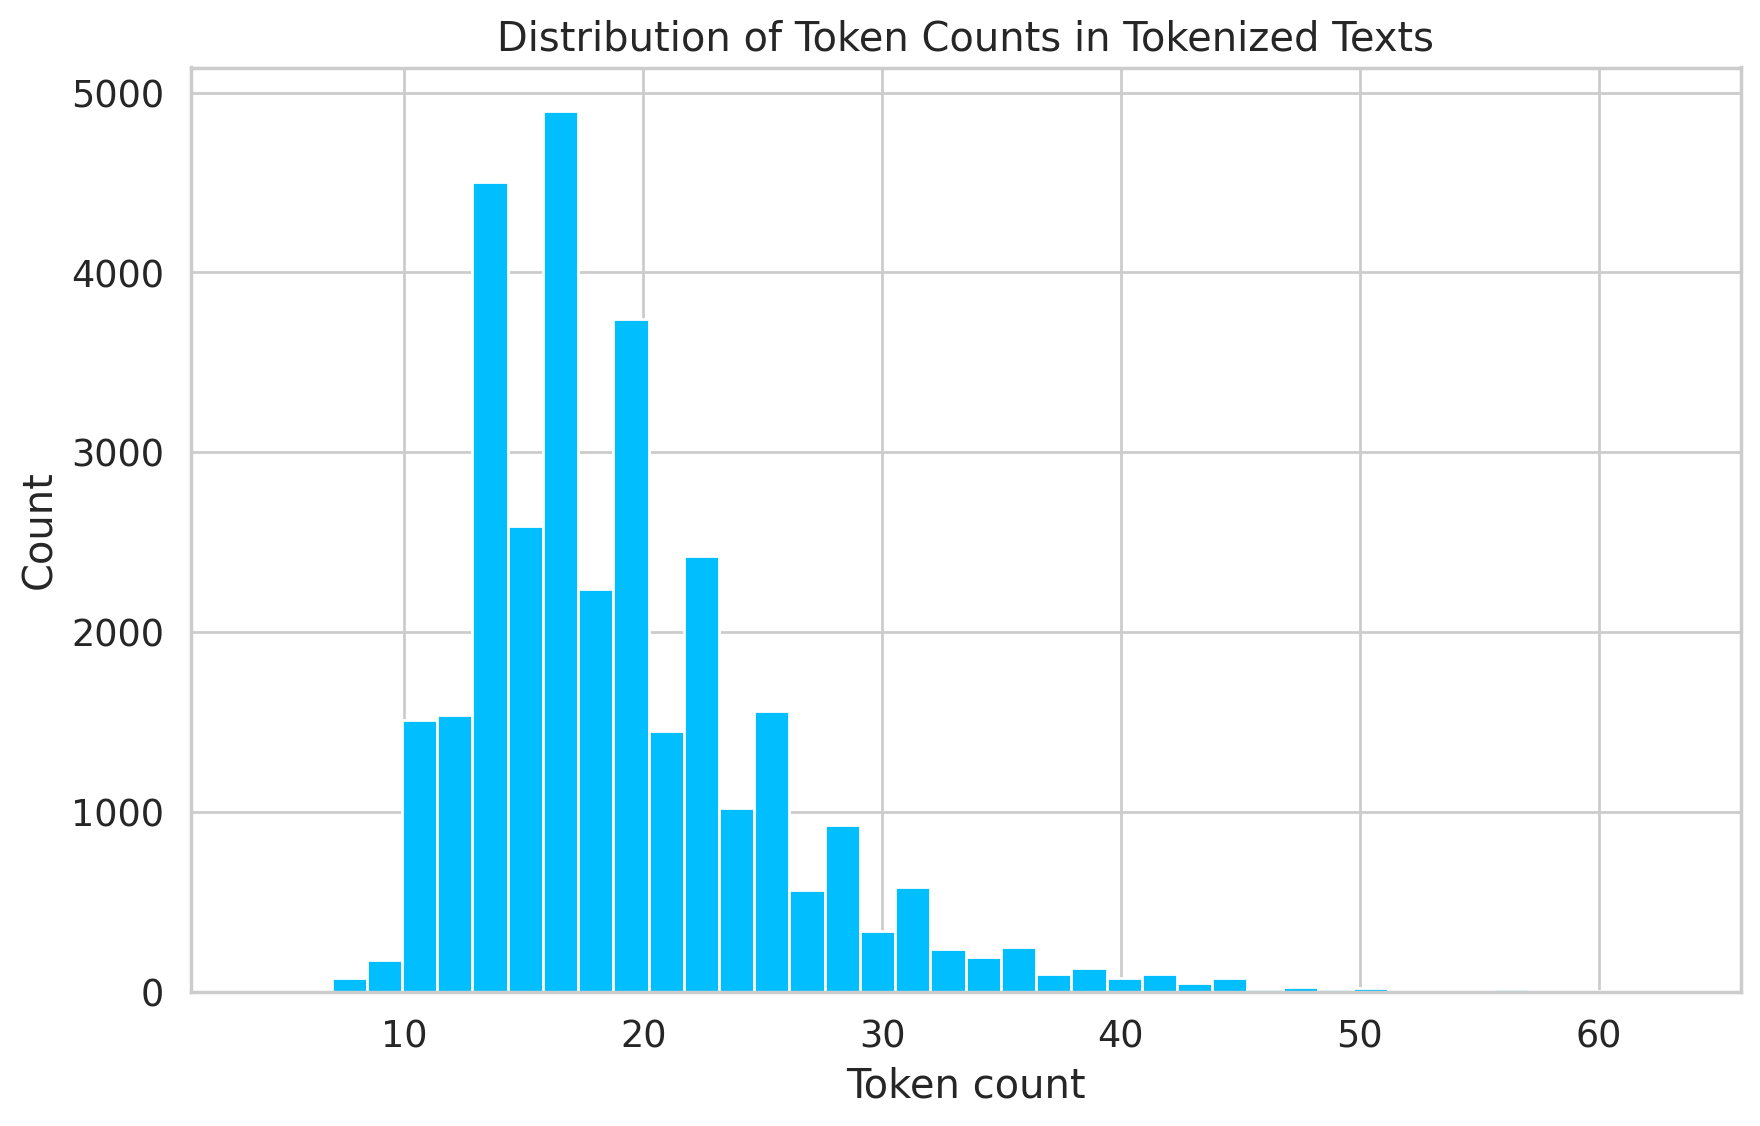

In [10]:
# Load tokenizer for a specific BERT model (replace with the desired model)
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

# Tokenize the text and get token counts
token_lens = [len(tokenizer(title, truncation=True, padding=False)['input_ids']) for title in train_text]

print("Maximum token length:",max(token_lens))

# Plot histogram of token counts
plt.figure(figsize=(10, 6))
pd.Series(token_lens).hist(bins=40)
plt.xlabel('Token count')
plt.ylabel('Count')
plt.title('Distribution of Token Counts in Tokenized Texts')
plt.show()

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Maximum token length: 94


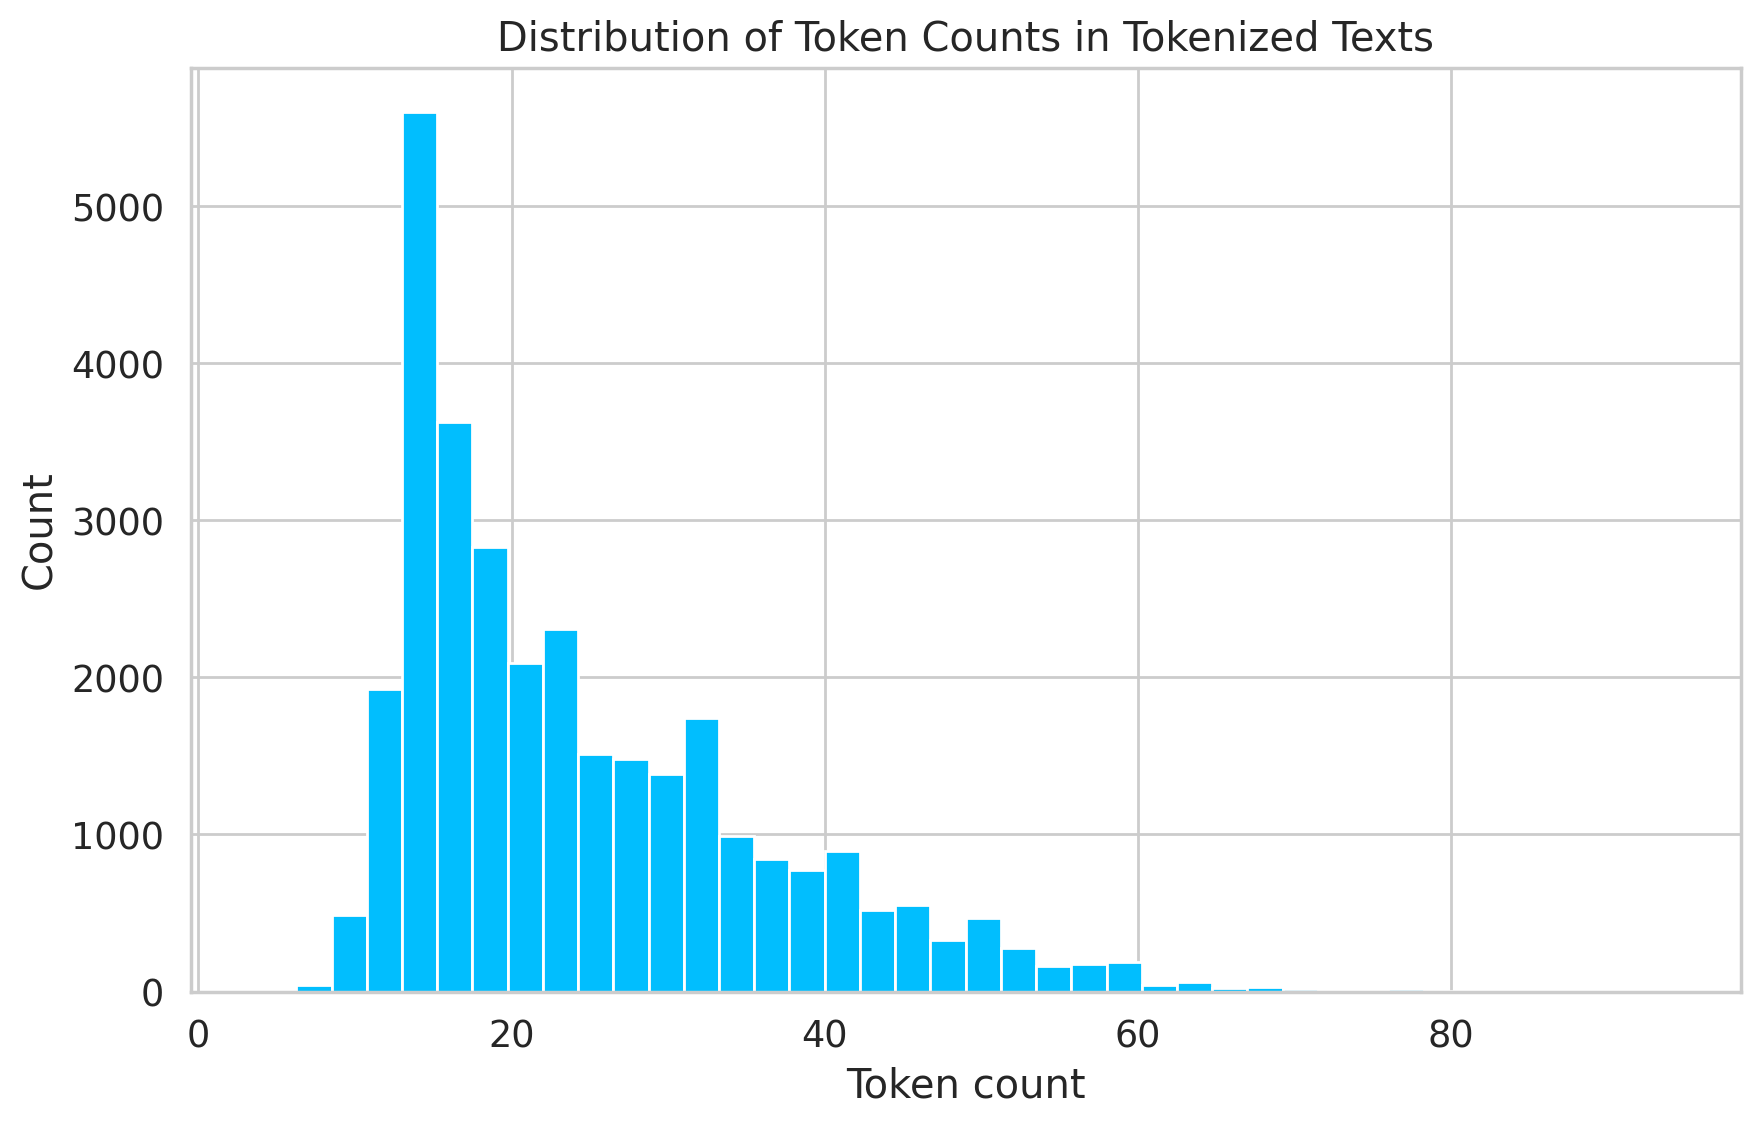

In [11]:
# Load tokenizer for a specific BERT model (replace with the desired model)
tokenizer = BertTokenizerFast.from_pretrained('bert-base-cased')

# Tokenize the text and get token counts
token_lens = [len(tokenizer(title, truncation=True, padding=False)['input_ids']) for title in train_text]

print("Maximum token length:",max(token_lens))

# Plot histogram of token counts
plt.figure(figsize=(10, 6))
pd.Series(token_lens).hist(bins=40)
plt.xlabel('Token count')
plt.ylabel('Count')
plt.title('Distribution of Token Counts in Tokenized Texts')
plt.show()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Maximum token length: 63


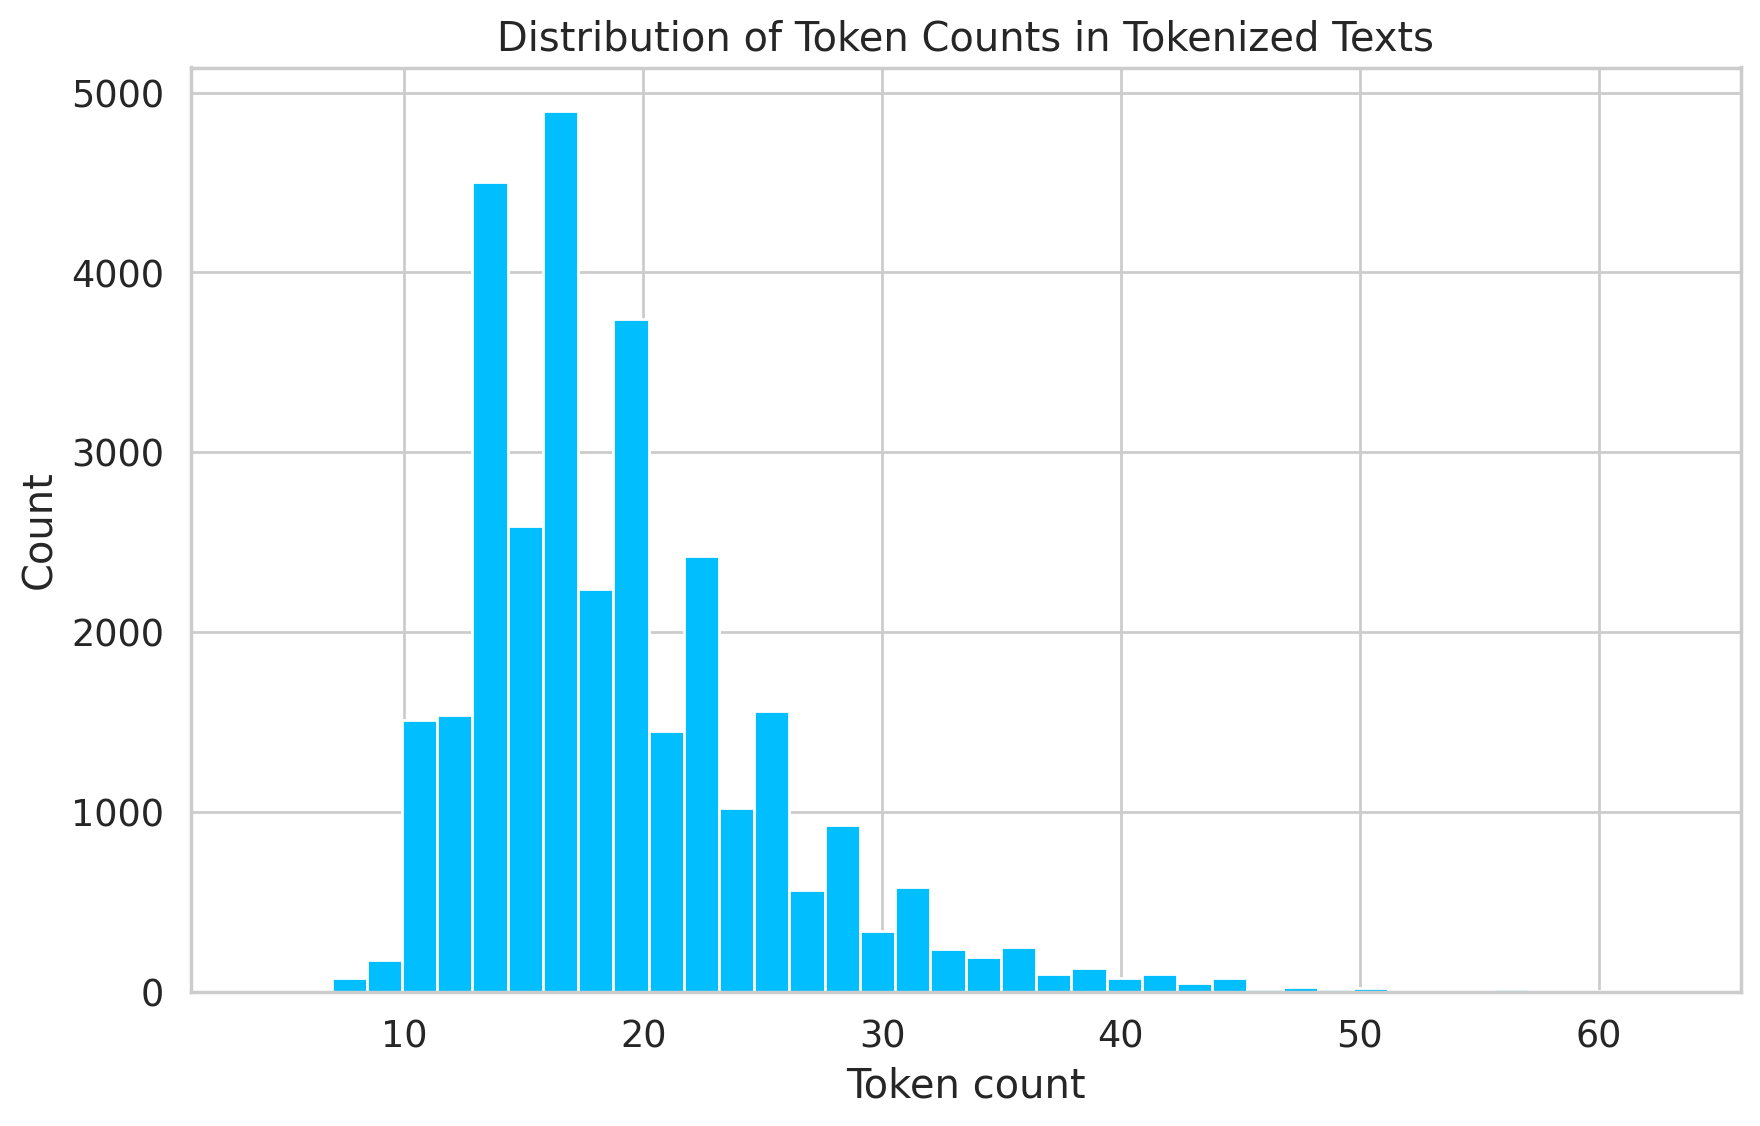

In [12]:
# Load tokenizer for a specific BERT model (replace with the desired model)
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize the text and get token counts
token_lens = [len(tokenizer(title, truncation=True, padding=False)['input_ids']) for title in train_text]

print("Maximum token length:",max(token_lens))

# Plot histogram of token counts
plt.figure(figsize=(10, 6))
pd.Series(token_lens).hist(bins=40)
plt.xlabel('Token count')
plt.ylabel('Count')
plt.title('Distribution of Token Counts in Tokenized Texts')
plt.show()

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

Maximum token length: 94


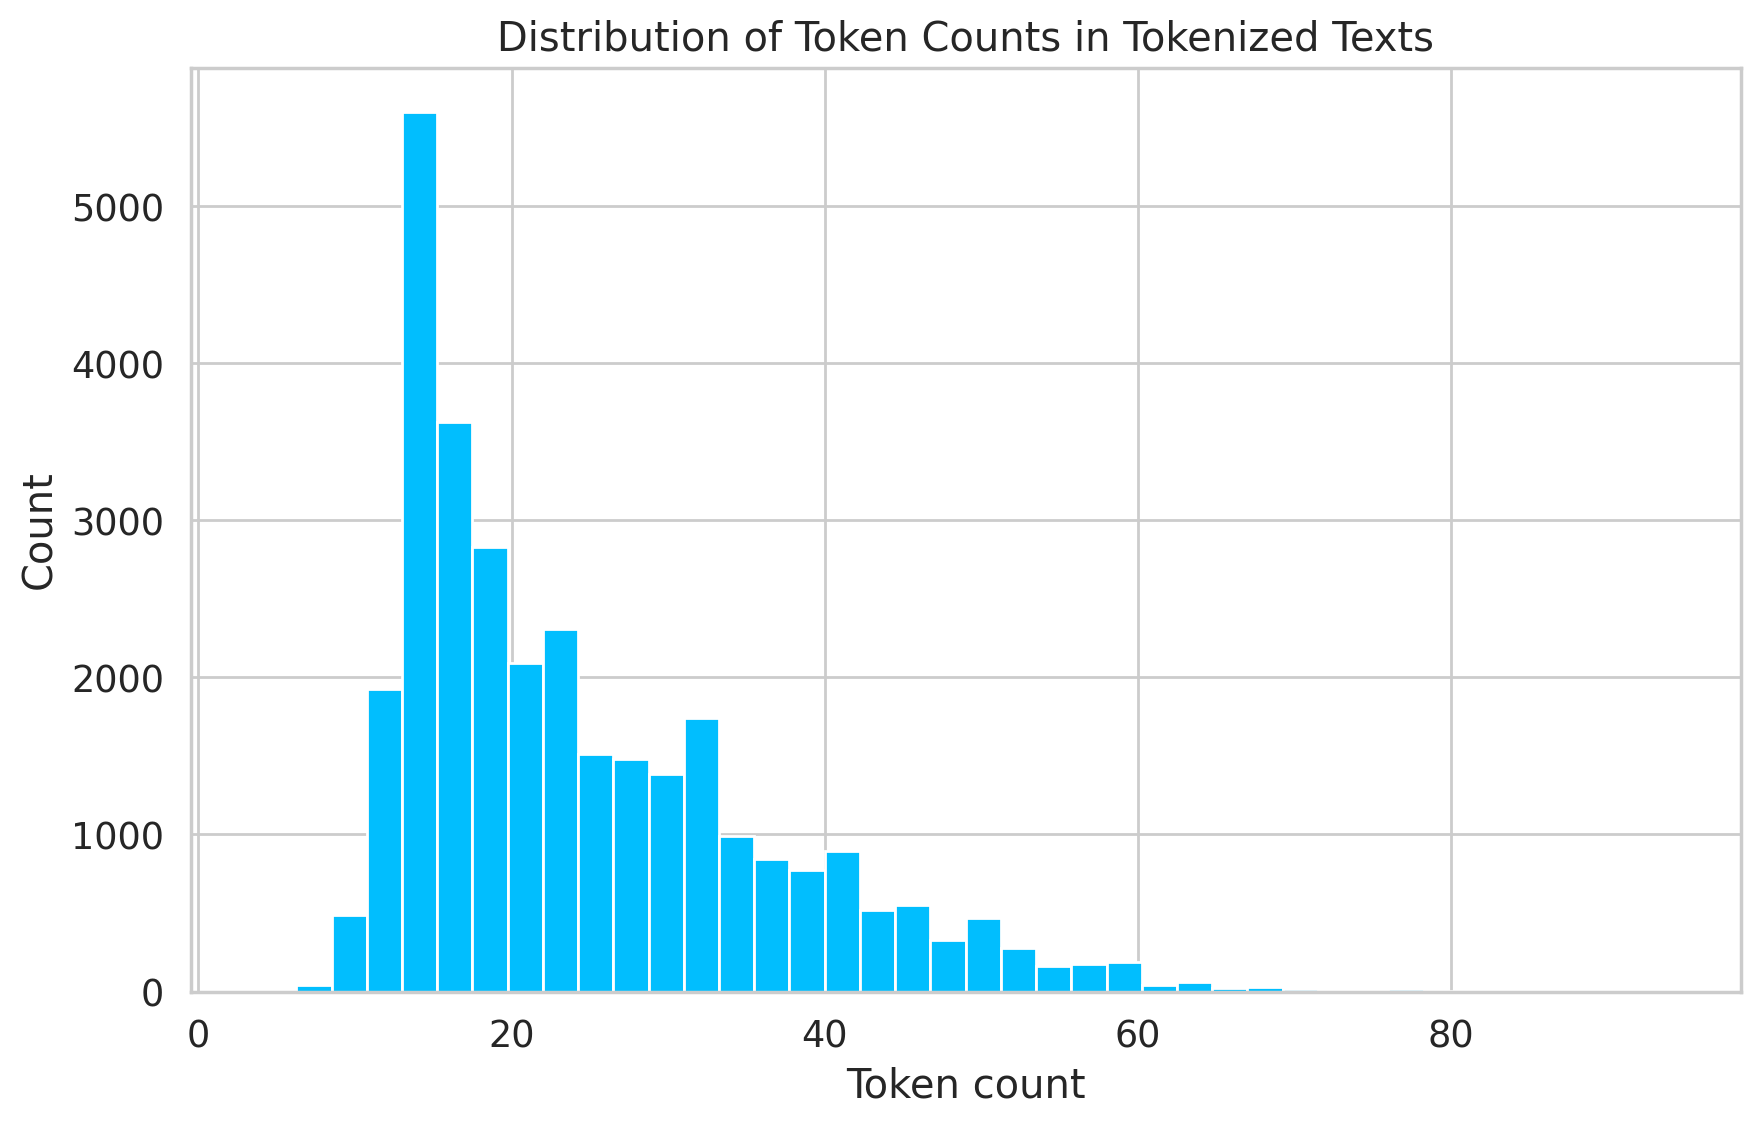

In [13]:
# Load tokenizer for a specific BERT model (replace with the desired model)
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-cased')

# Tokenize the text and get token counts
token_lens = [len(tokenizer(title, truncation=True, padding=False)['input_ids']) for title in train_text]

print("Maximum token length:",max(token_lens))

# Plot histogram of token counts
plt.figure(figsize=(10, 6))
pd.Series(token_lens).hist(bins=40)
plt.xlabel('Token count')
plt.ylabel('Count')
plt.title('Distribution of Token Counts in Tokenized Texts')
plt.show()

In [14]:
# Function to load tokenizer and model
def load_model_and_tokenizer(model_name):
    if model_name == 'distilbert':
        tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
        model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
    elif model_name == 'distilbert-cased':
        tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-cased')
        model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-cased', num_labels=2)
    elif model_name == 'bert-base-cased':
        tokenizer = BertTokenizerFast.from_pretrained('bert-base-cased')
        model = BertForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)
    elif model_name == 'bert-base-uncased':
        tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
        model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
    return tokenizer, model

In [15]:
# Max length for models (the majority of titles have word length under 100 so set the MAX_LENGTH to 128 to provide some buffer)
MAX_LENGTH = 128

In [16]:
# Tokenize and encode sequences in the train, validation, and test sets
def tokenize_data(tokenizer, texts):
    return tokenizer.batch_encode_plus(texts, max_length=MAX_LENGTH, padding='max_length', truncation=True)

In [17]:
# Convert lists to tensors for each variant
def convert_to_tensors(tokens, labels):
    return (
        torch.tensor(tokens['input_ids']),
        torch.tensor(tokens['attention_mask']),
        torch.tensor(labels.tolist())
    )

In [18]:
# Load and tokenize data for each model
model_variants = ['distilbert', 'distilbert-cased', 'bert-base-cased', 'bert-base-uncased']
tokens = {}
for variant in model_variants:
    tokenizer, model = load_model_and_tokenizer(variant)
    tokens[variant] = {
        'train': tokenize_data(tokenizer, train_text.tolist()),
        'val': tokenize_data(tokenizer, val_text.tolist()),
        'test': tokenize_data(tokenizer, test_text.tolist()),
    }

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
# Convert to tensors
tensor_data = {}
for variant in model_variants:
    train_seq, train_mask, train_y = convert_to_tensors(tokens[variant]['train'], train_labels)
    val_seq, val_mask, val_y = convert_to_tensors(tokens[variant]['val'], val_labels)
    test_seq, test_mask, test_y = convert_to_tensors(tokens[variant]['test'], test_labels)
    tensor_data[variant] = {
        'train': (train_seq, train_mask, train_y),
        'val': (val_seq, val_mask, val_y),
        'test': (test_seq, test_mask, test_y)
    }

In [20]:
def create_data_loader(seq, mask, labels, batch_size):
    data = TensorDataset(seq, mask, labels)
    sampler = RandomSampler(data)
    return DataLoader(data, sampler=sampler, batch_size=batch_size)

In [21]:
# Define hyperparameters for tuning
def objective(trial):
    model_name = trial.suggest_categorical('model_name', model_variants)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-6, 1e-3)
    epochs = trial.suggest_int('epochs', 5, 10)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-3)
    warmup_steps = trial.suggest_int('warmup_steps', 0, 100)

    train_dataloader = create_data_loader(*tensor_data[model_name]['train'], batch_size)
    val_dataloader = create_data_loader(*tensor_data[model_name]['val'], batch_size)

    model = load_model_and_tokenizer(model_name)[1]
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    total_steps = len(train_dataloader) * epochs
    scheduler = transformers.get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_dataloader, desc=f'Training Epoch {epoch + 1}/{epochs}'):
            batch = [b.to(device) for b in batch]
            sent_id, mask, labels = batch
            model.zero_grad()
            preds = model(sent_id, attention_mask=mask).logits
            loss = nn.CrossEntropyLoss()(preds, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)
        print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}')

        # Validation
        model.eval()
        total_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_dataloader, desc=f'Validation Epoch {epoch + 1}/{epochs}'):
                batch = [b.to(device) for b in batch]
                sent_id, mask, labels = batch
                preds = model(sent_id, attention_mask=mask).logits
                loss = nn.CrossEntropyLoss()(preds, labels)
                total_loss += loss.item()

        avg_val_loss = total_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        print(f'Epoch {epoch+1}, Val Loss: {avg_val_loss:.4f}')

    return avg_val_loss  # Return average validation loss for Optuna

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED_VALUE))
study.optimize(objective, n_trials=16)

print('Number of finished trials: {}'.format(len(study.trials)))
print('Best trial:')
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params:")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2024-10-22 21:51:47,916] A new study created in memory with name: no-name-bd3791c9-83c6-4b90-808f-9731482ec861
/tmp/ipykernel_23/3674895497.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-6, 1e-3)
/tmp/ipykernel_23/3674895497.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-3)
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAI

Epoch 1, Train Loss: 0.0462


Validation Epoch 1/9: 100%|██████████| 106/106 [00:12<00:00,  8.46it/s]


Epoch 1, Val Loss: 0.0031


Training Epoch 2/9: 100%|██████████| 492/492 [02:56<00:00,  2.78it/s]


...

Epoch 4, Val Loss: 0.0006


Training Epoch 5/5: 100%|██████████| 983/983 [05:47<00:00,  2.83it/s]


Epoch 5, Train Loss: 0.0010


Validation Epoch 5/5: 100%|██████████| 211/211 [00:22<00:00,  9.44it/s]
[I 2024-10-23 08:41:15,339] Trial 15 finished with value: 0.0006828570997541643 and parameters: {'model_name': 'bert-base-cased', 'batch_size': 32, 'learning_rate': 3.8958669871143774e-06, 'epochs': 5, 'weight_decay': 2.9059613560098313e-06, 'warmup_steps': 16}. Best is trial 12 with value: 0.00028661976373432784.


Epoch 5, Val Loss: 0.0007
Number of finished trials: 16
Best trial:
  Value: 0.00028661976373432784
  Params:
    model_name: bert-base-cased
    batch_size: 32
    learning_rate: 9.339187704713348e-06
    epochs: 7
    weight_decay: 3.0210752570094983e-06
    warmup_steps: 22


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Training Epoch 1/7: 100%|██████████| 983/983 [05:48<00:00,  2.82it/s]


Epoch 1, Train Loss: 0.0349, Train Accuracy: 0.9900


Validation Epoch 1/7: 100%|██████████| 211/211 [00:22<00:00,  9.43it/s]


Epoch 1, Val Loss: 0.0035, Val Accuracy: 0.9990


Training Epoch 2/7: 100%|██████████| 983/983 [05:47<00:00,  2.83it/s]


...

Epoch 6, Val Loss: 0.0014, Val Accuracy: 0.9997


Training Epoch 7/7: 100%|██████████| 983/983 [05:47<00:00,  2.83it/s]


Epoch 7, Train Loss: 0.0001, Train Accuracy: 1.0000


Validation Epoch 7/7: 100%|██████████| 211/211 [00:22<00:00,  9.45it/s]


Epoch 7, Val Loss: 0.0012, Val Accuracy: 0.9999
Best model saved with validation loss: 0.0005


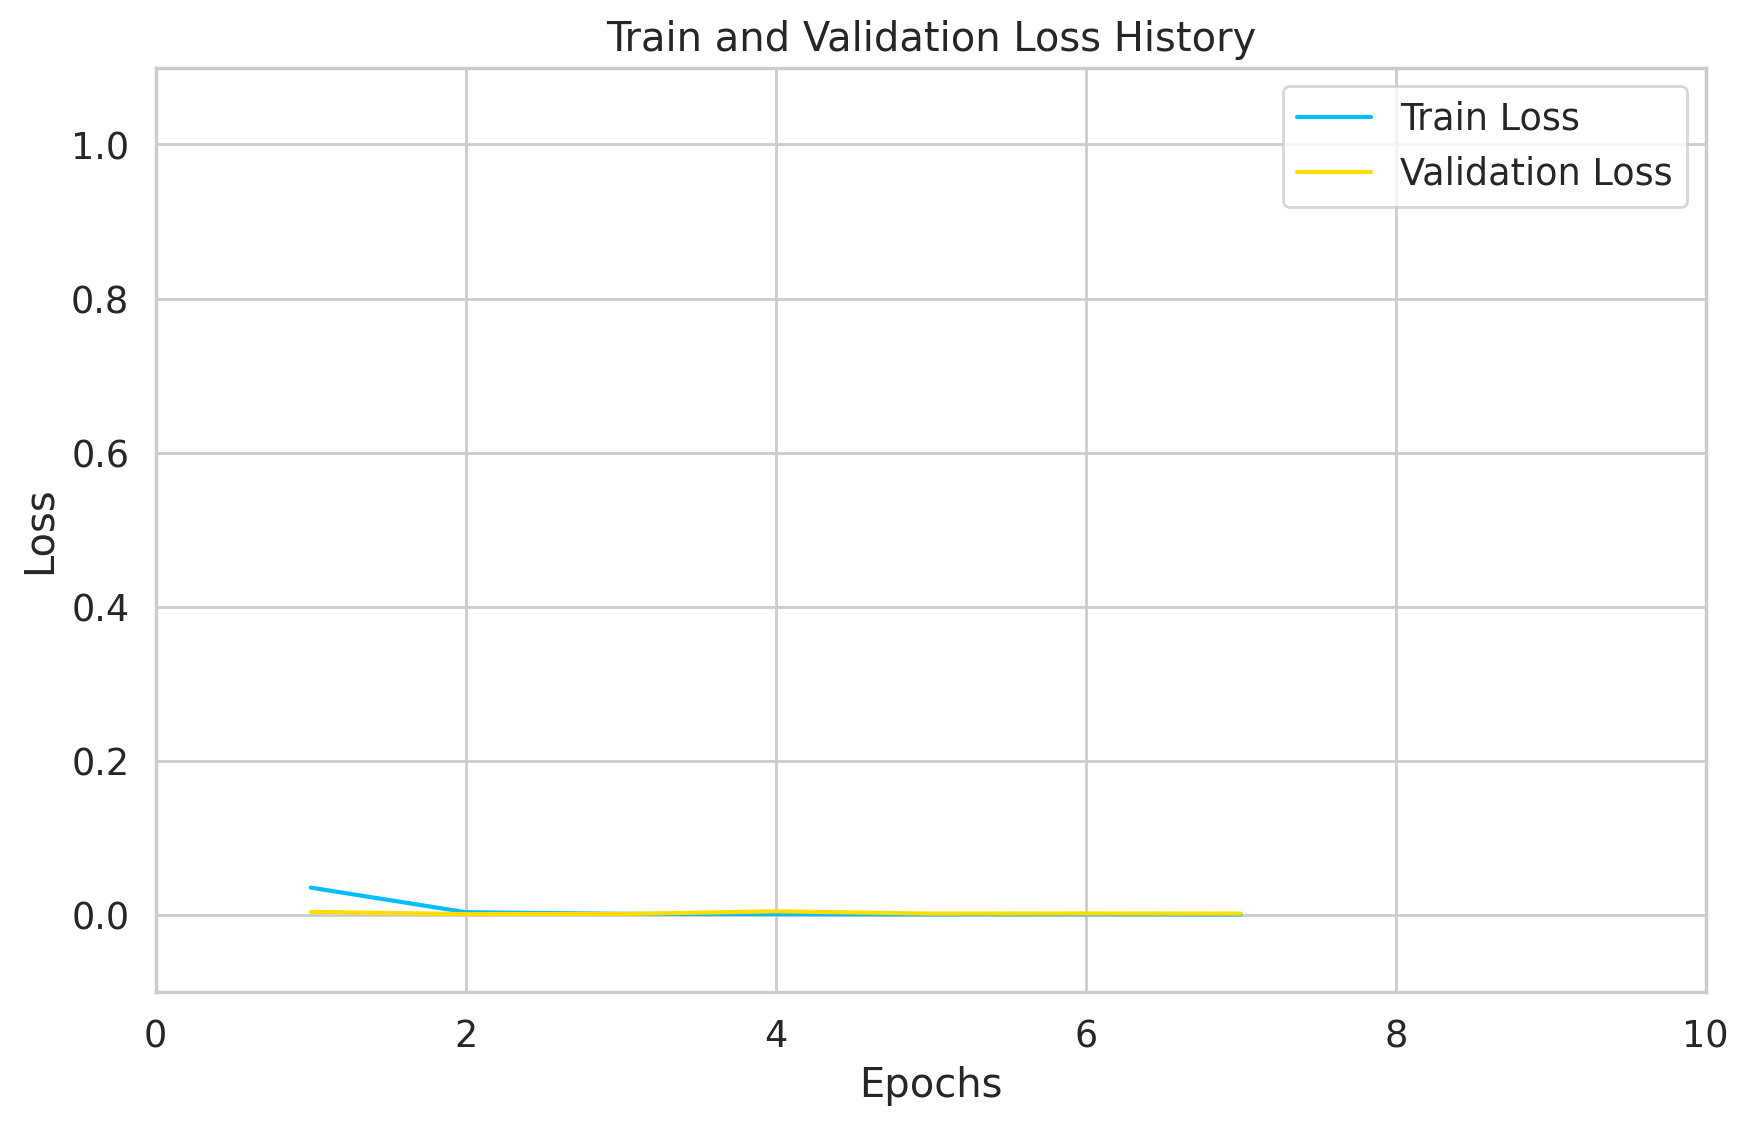

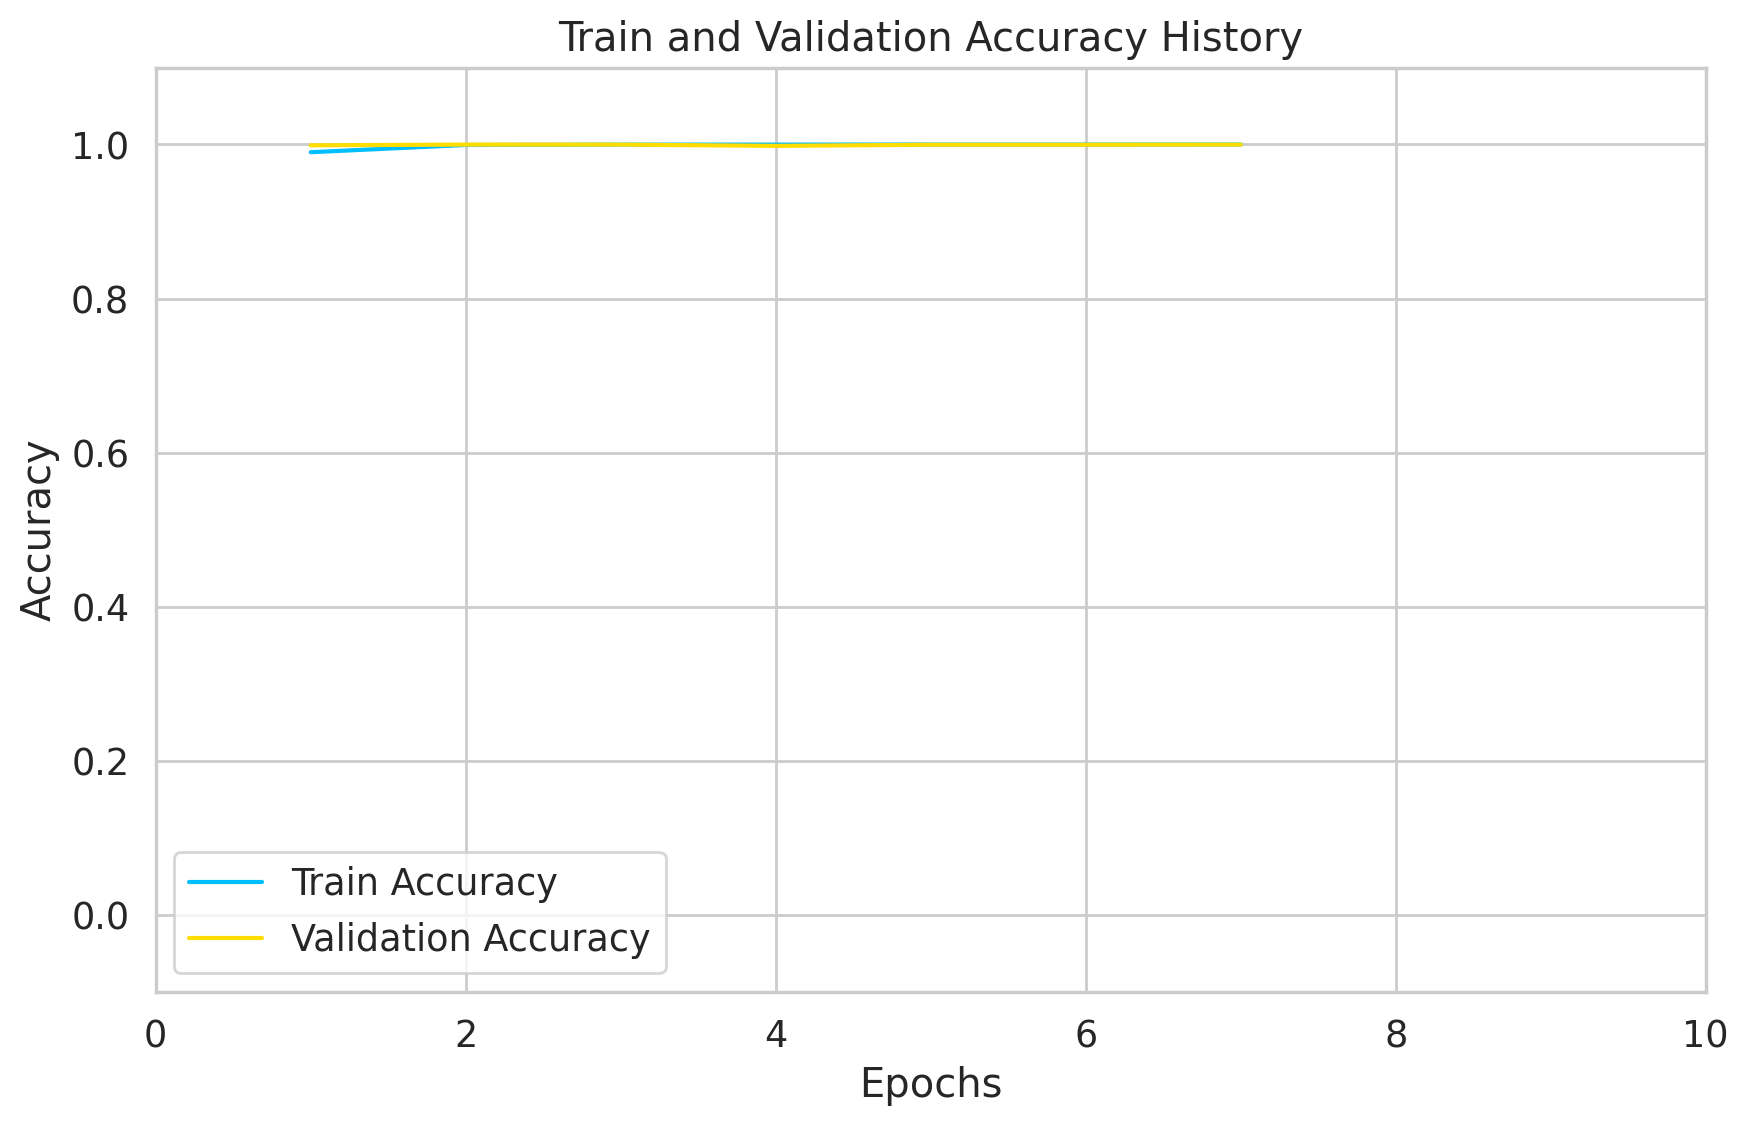

Testing: 100%|██████████| 211/211 [00:22<00:00,  9.48it/s]

Test Loss: 0.0000
Test Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3197
           1       1.00      1.00      1.00      3538

    accuracy                           1.00      6735
   macro avg       1.00      1.00      1.00      6735
weighted avg       1.00      1.00      1.00      6735



In [22]:
# Use the best parameters to retrain the model

best_params = trial.params
model_name = best_params['model_name']
batch_size = best_params['batch_size']
learning_rate = best_params['learning_rate']
epochs = best_params['epochs']
weight_decay = best_params['weight_decay']
warmup_steps = best_params['warmup_steps']

# BEST MODEL PARAMETERS
# model_name = "bert-base-cased"
# batch_size = 32
# learning_rate = 9.339187704713348e-06
# epochs = 7
# weight_decay = 3.0210752570094983e-06
# warmup_steps = 22

# Initialize variables for tracking the best model
best_val_loss = float('inf')
best_model_state = None

train_dataloader = create_data_loader(tensor_data[model_name]['train'][0], tensor_data[model_name]['train'][1], tensor_data[model_name]['train'][2], batch_size)
val_dataloader = create_data_loader(tensor_data[model_name]['val'][0], tensor_data[model_name]['val'][1], tensor_data[model_name]['val'][2], batch_size)

model = load_model_and_tokenizer(model_name)[1]
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

total_steps = len(train_dataloader) * epochs
scheduler = transformers.get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    
    for batch in tqdm(train_dataloader, desc=f'Training Epoch {epoch + 1}/{epochs}'):
        batch = [b.to(device) for b in batch]
        sent_id, mask, labels = batch
        model.zero_grad()
        preds = model(sent_id, attention_mask=mask).logits
        loss = nn.CrossEntropyLoss()(preds, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        correct_predictions += (torch.argmax(preds, dim=1) == labels).sum().item()
        total_predictions += labels.size(0)

    # Calculate train loss
    avg_train_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    
    # Calculate train accuracy
    train_accuracy = correct_predictions / total_predictions
    train_accuracies.append(train_accuracy)
    
    print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

    # Validation
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    
    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f'Validation Epoch {epoch + 1}/{epochs}'):
            batch = [b.to(device) for b in batch]
            sent_id, mask, labels = batch
            preds = model(sent_id, attention_mask=mask).logits
            
            loss = nn.CrossEntropyLoss()(preds, labels)
            total_loss += loss.item()
            
            correct_predictions += (torch.argmax(preds, dim=1) == labels).sum().item()
            total_predictions += labels.size(0)

    # Calculate validation loss
    avg_val_loss = total_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    
    # Calculate validation accuracy
    val_accuracy = correct_predictions / total_predictions
    val_accuracies.append(val_accuracy)
    
    print(f'Epoch {epoch+1}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')
    
    # Check if the current validation loss is the best
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()  # Save the model state

# After training, save the best model
torch.save(best_model_state, f'best_model_{model_name}.pth')
print(f'Best model saved with validation loss: {best_val_loss:.4f}')        
        
# Plotting Train/Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Loss History')
plt.legend()
plt.xlim([0, 10]);
plt.ylim([-0.1, 1.1]);
plt.show()

# Plotting Train/Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and Validation Accuracy History')
plt.legend()
plt.xlim([0, 10]);
plt.ylim([-0.1, 1.1]);
plt.show()
    
# Testing Phase
test_dataloader = create_data_loader(tensor_data[model_name]['test'][0], tensor_data[model_name]['test'][1], tensor_data[model_name]['test'][2], batch_size)

model.eval()
test_preds, test_labels = [], []
test_loss = 0

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc='Testing'):
        batch = [b.to(device) for b in batch]
        sent_id, mask, labels = batch
        preds = model(sent_id, attention_mask=mask).logits
        
        # Calculate loss
        loss = nn.CrossEntropyLoss()(preds, labels)
        test_loss += loss.item()
        
        test_preds.extend(torch.argmax(preds, dim=1).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Average test loss
avg_test_loss = test_loss / len(test_dataloader)
print(f'Test Loss: {avg_test_loss:.4f}')

# Calculate test accuracy
test_accuracy = np.sum(np.array(test_preds) == np.array(test_labels)) / len(test_labels)
print(f'Test Accuracy: {test_accuracy:.4f}')

# Classification Report
print(classification_report(test_labels, test_preds))

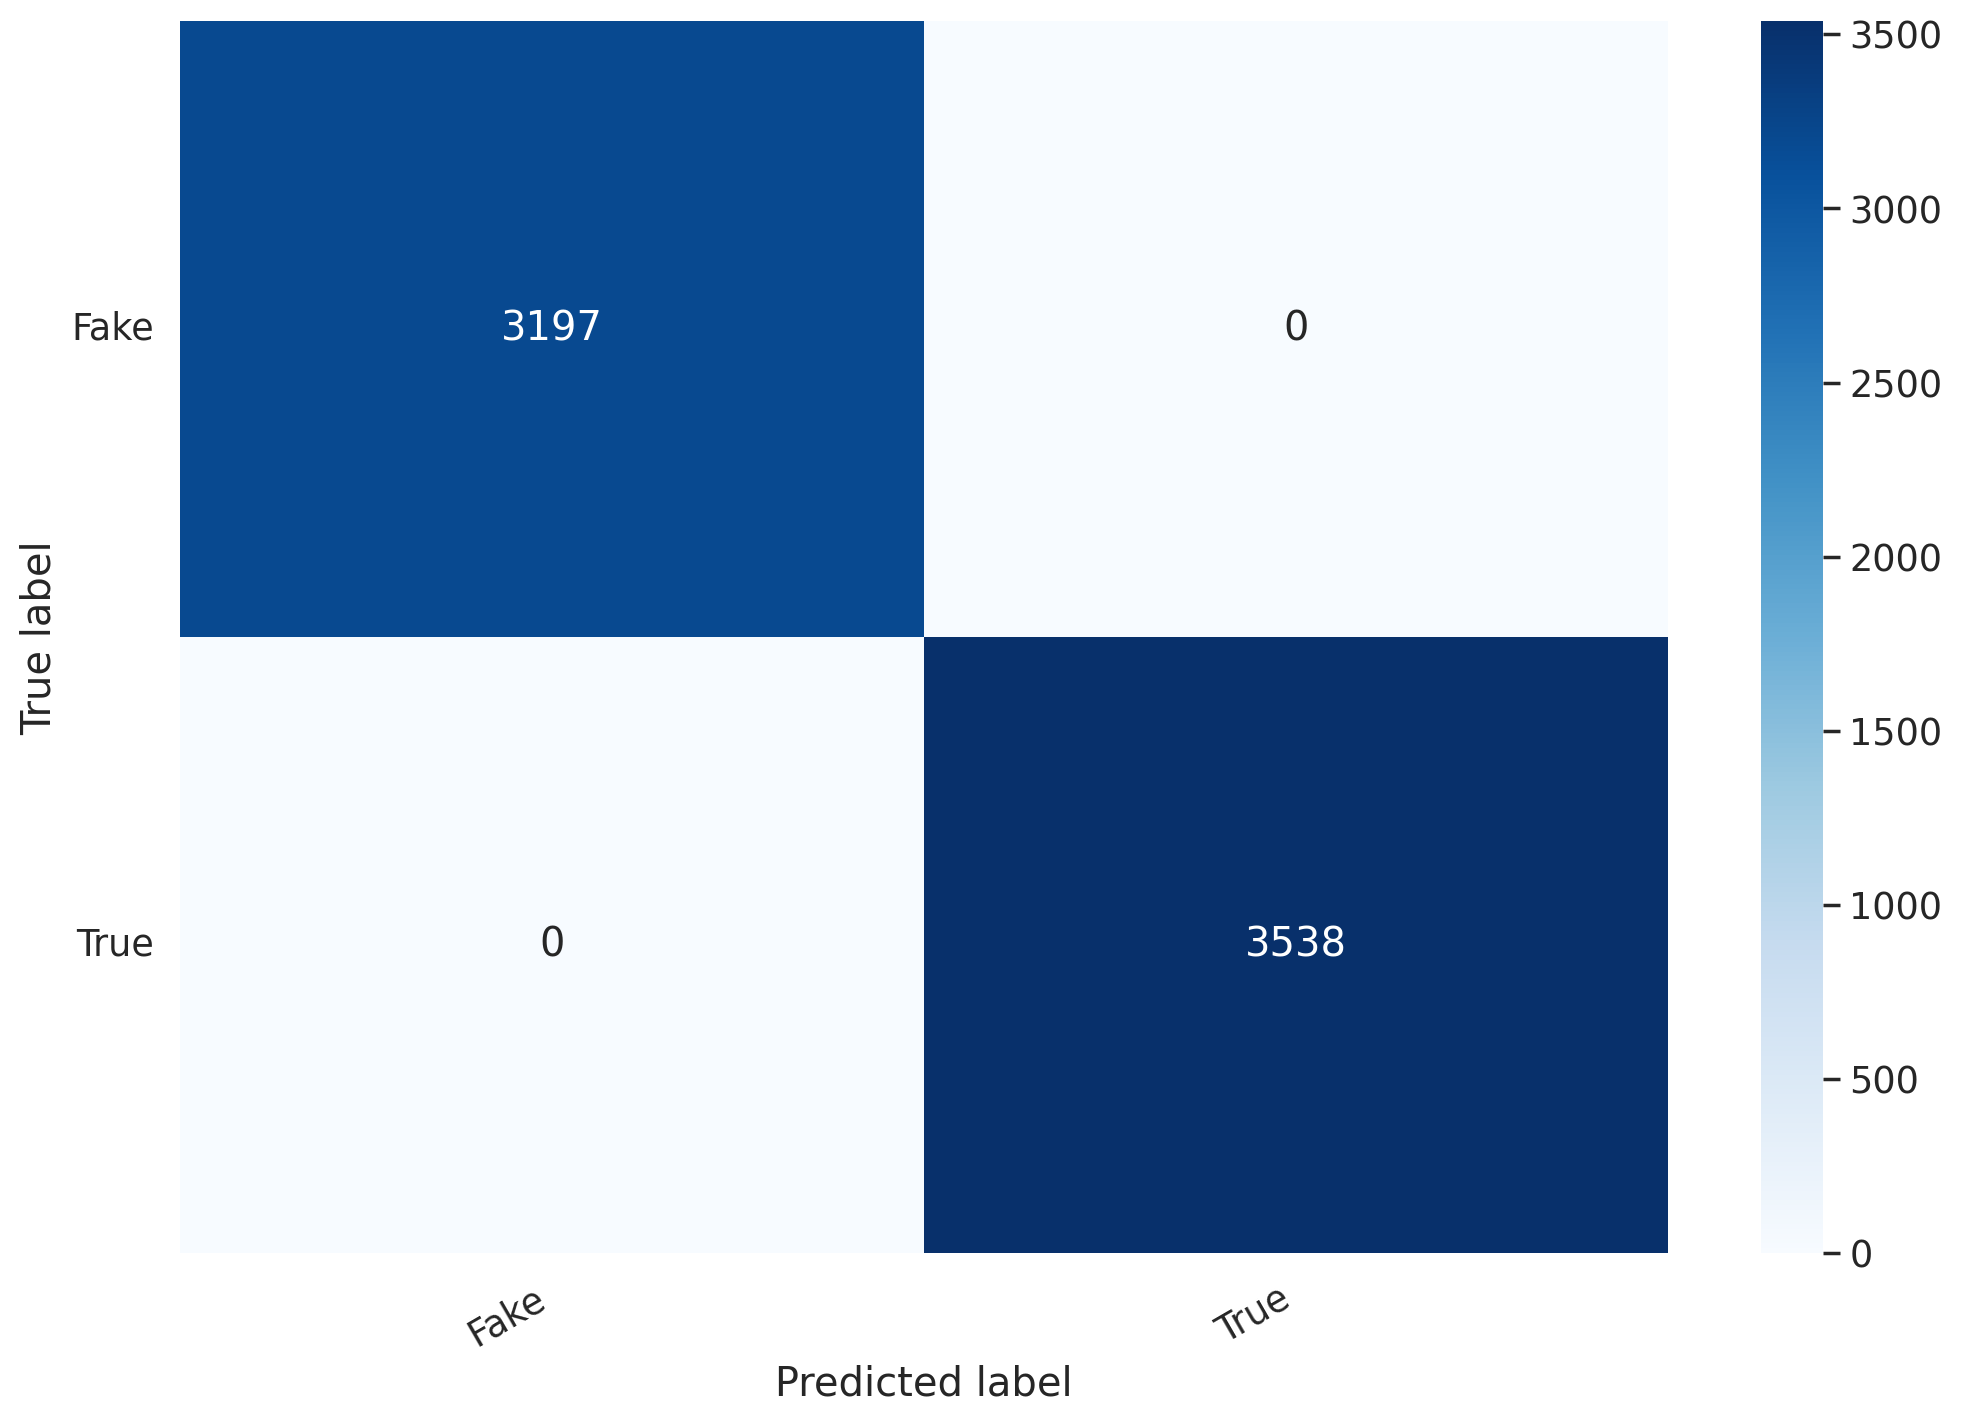

In [23]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True label')
  plt.xlabel('Predicted label');

class_names = ['Fake', 'True']
cm = confusion_matrix(test_labels, test_preds)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)

In [24]:
# Function to predict labels for unseen data
def predict_unseen_data(model, tokenizer, unseen_texts, max_length=MAX_LENGTH):
    model.eval()
    tokens = tokenizer.batch_encode_plus(unseen_texts, max_length=max_length, padding='max_length', truncation=True)
    
    input_ids = torch.tensor(tokens['input_ids']).to(device)
    attention_mask = torch.tensor(tokens['attention_mask']).to(device)

    with torch.no_grad():
        preds = model(input_ids, attention_mask=attention_mask).logits
        predictions = torch.argmax(preds, dim=1).cpu().numpy()
    
    return predictions

# Predictions on unseen data
unseen_data = [
    "Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing",
    "WATCH: George W. Bush Calls Out Trump For Supporting White Supremacy",
    "U.S. lawmakers question businessman at 2016 Trump Tower meeting: sources",
    "Trump administration issues new rules on U.S. visa waivers"
]

# Load the best tokenizer
tokenizer = load_model_and_tokenizer(model_name)[0]

# Make predictions
predictions = predict_unseen_data(model, tokenizer, unseen_data)
print("Predictions on unseen data:", predictions)

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Predictions on unseen data: [1 1 0 0]
